### Predictive Modelling

####  *AUTHOR:* Ehsan Farahbakhsh
####  *CONTACT:* e.farahbakhsh@sydney.edu.au
####  *DATE last modified:* 16/09/2025

This notebook applies machine learning to identify mineralised regions within arc–backarc environments. Using a Random Forest model trained on features primarily extracted along trench lines in subduction zones, we investigate the factors that drive mineralisation and the locations where deposits are most likely to form. The analysis focuses on four key aspects: training a predictive model to locate mineralisation, determining which features contribute most to deposit formation, quantifying uncertainty to highlight areas of higher and lower confidence, and enabling users to assess model accuracy. Finally, the predictions are mapped through geological time in an interactive map, providing a practical tool to support exploration efforts.

We begin by importing the required libraries:

In [1]:
# Import libraries
from ipywidgets import interact
import os

import cartopy.crs as ccrs
import joblib
from joblib import Parallel, delayed
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import shap
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import PartialDependenceDisplay, partial_dependence, permutation_importance
from sklearn.metrics import accuracy_score, brier_score_loss, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import RepeatedStratifiedKFold, train_test_split
from skopt import BayesSearchCV
from skopt.space import Categorical, Integer, Real
from tqdm import tqdm

# Note: Ensure the 'lib' folder is located in the same folder as this notebook
from lib.predictive_modelling import *
from lib.feature_extraction import *
from lib.plot import *

# Load configuration parameters (e.g., paths, model names)
from parameters import parameters

### Setup

As defined in `parameters.py`, the cell below configures the analysis parameters and specifies the paths to input/output files and directories. You can also specify the number of cores to use by setting an appropriate value for the `n_jobs` variable at the end of the cell.

**Note:** You can modify the analysis settings directly in `parameters.py`, located in the same folder as this notebook. The file is structured as a dictionary; look for keys such as `timespan` and `temporal_resolution` to adjust their values as needed.

In [2]:
# Set up temporal analysis parameters
temporal_resolution = parameters["temporal_resolution"]
time_min = parameters["timespan"]["min"] # Youngest time to analyse
time_max = parameters["timespan"]["max"] # Oldest time to analyse
# Create an array of time steps for analysis (e.g., 0, 1, 2, ... Ma)
time_steps = range(time_min, time_max + temporal_resolution, temporal_resolution)

columns_to_drop_backarc = parameters["columns_to_drop_backarc"]

# Directory paths for inputs and outputs
plate_model_dir = parameters["plate_model_dir"]
inputs_dir = parameters["inputs_dir"]
outputs_dir = parameters["outputs_dir"]
ml_dir = parameters["ml_dir"]
backarc_prob_grids_dir = parameters["backarc_prob_grids_dir"]
backarc_entropy_grids_dir = parameters["backarc_entropy_grids_dir"]
backarc_vote_variance_grids_dir = parameters["backarc_vote_variance_grids_dir"]
backarc_prob_maps_dir = parameters["backarc_prob_maps_dir"]
backarc_entropy_maps_dir = parameters["backarc_entropy_maps_dir"]
backarc_vote_variance_maps_dir = parameters["backarc_vote_variance_maps_dir"]

# Data filenames
Xy_train_new_filename = parameters["Xy_train_new_filename"]
Xy_rf_train_filename = parameters["Xy_rf_train_filename"]
Xy_rf_val_filename = parameters["Xy_rf_val_filename"]
Xy_rf_test_filename = parameters["Xy_rf_test_filename"]
Xy_pos_test_filename = parameters["Xy_pos_test_filename"]
gini_importances_filename = parameters["gini_importances_filename"]
permutation_importances_filename = parameters["permutation_importances_filename"]
shap_values_filename = parameters["shap_values_filename"]
features_shap_test_filename = parameters["features_shap_test_filename"]
backarc_data_filename = parameters["backarc_data_filename"]
backarc_prob_filename = parameters["backarc_prob_filename"]
deposit_coords_recon_all_filename = parameters["deposit_coords_recon_all_filename"]

model_rf_filename = parameters["model_rf_filename"]
model_rf_calibrated_filename = parameters["model_rf_calibrated_filename"]
robust_scaler_filename = parameters["robust_scaler_filename"]

# Construct full directory paths
ml_dir = os.path.join(outputs_dir, ml_dir)
backarc_prob_grids_dir = os.path.join(ml_dir, backarc_prob_grids_dir)
backarc_entropy_grids_dir = os.path.join(ml_dir, backarc_entropy_grids_dir)
backarc_vote_variance_grids_dir = os.path.join(ml_dir, backarc_vote_variance_grids_dir)
backarc_prob_maps_dir = os.path.join(ml_dir, backarc_prob_maps_dir)
backarc_entropy_maps_dir = os.path.join(ml_dir, backarc_entropy_maps_dir)
backarc_vote_variance_maps_dir = os.path.join(ml_dir, backarc_vote_variance_maps_dir)

# Construct full file paths
Xy_train_new_filename = os.path.join(ml_dir, Xy_train_new_filename)
Xy_rf_train_filename = os.path.join(ml_dir, Xy_rf_train_filename)
Xy_rf_val_filename = os.path.join(ml_dir, Xy_rf_val_filename)
Xy_rf_test_filename = os.path.join(ml_dir, Xy_rf_test_filename)
Xy_pos_test_filename = os.path.join(ml_dir, Xy_pos_test_filename)
gini_importances_filename = os.path.join(ml_dir, gini_importances_filename)
permutation_importances_filename = os.path.join(ml_dir, permutation_importances_filename)
shap_values_filename = os.path.join(ml_dir, shap_values_filename)
features_shap_test_filename = os.path.join(ml_dir, features_shap_test_filename)
backarc_data_filename = os.path.join(outputs_dir, backarc_data_filename)
backarc_prob_filename = os.path.join(ml_dir, backarc_prob_filename)
deposit_coords_recon_all_filename = os.path.join(outputs_dir, deposit_coords_recon_all_filename)

model_rf_filename = os.path.join(ml_dir, model_rf_filename)
model_rf_calibrated_filename = os.path.join(ml_dir, model_rf_calibrated_filename)
robust_scaler_filename = os.path.join(ml_dir, robust_scaler_filename)

agegrid_dir = os.path.join(inputs_dir, "SeafloorAge")

# Number of cores to be used for running this notebook
n_jobs = 20

### Random Forest

We train a machine learning model to distinguish between mineralised and barren areas. The Random Forest algorithm is chosen because it effectively handles complex geological relationships and diverse types of data.

The key steps include:
- Removing positive samples identified through the positive-unlabelled bagging method and retaining only those random samples labelled as negative.  
- Balancing the dataset by ensuring an equal number of positive and negative samples, preventing model bias.  
- Splitting the data into training, validation, and testing sets for proper evaluation.  
- Tuning hyperparameters to optimise model performance.  
- Calibrating the model so that its predictions better capture real-world uncertainty.

In [3]:
# Load and prepare training data
Xy_train_new = pd.read_csv(Xy_train_new_filename)
# Xy_train_new["label"] = Xy_train_new["label"].replace(2, 1)
# Remove samples labelled as 2 (positive samples identified by the 
# positive-unlabelled bagging method) to improve model reliability 
# by training only on definitive samples.
Xy_train_new = Xy_train_new[Xy_train_new["label"] != 2]

# Address imbalance by matching positive and negative sample sizes
# This prevents the model from being biased toward the majority class
Xy_train_new_ones = Xy_train_new[Xy_train_new["label"] == 1]
Xy_train_new_zeros = Xy_train_new[Xy_train_new["label"] == 0]
Xy_train_new_zeros_sampled = Xy_train_new_zeros.sample(n=len(Xy_train_new_ones), random_state=42)
Xy_train_new = pd.concat([Xy_train_new_ones, Xy_train_new_zeros_sampled])
Xy_train_new = Xy_train_new.sample(frac=1, random_state=42).reset_index(drop=True)

print("Number of positive samples:", len(Xy_train_new_ones))
print("Number of negative samples:", len(Xy_train_new_zeros_sampled))

# Separate features from labels
features_rf = Xy_train_new.copy()
features_rf = features_rf.drop("label", axis=1)
labels_rf = Xy_train_new["label"]

if os.path.isfile(model_rf_calibrated_filename):
    # Load existing model and data if available
    model_rf = joblib.load(model_rf_filename)
    model_rf_calibrated = joblib.load(model_rf_calibrated_filename)
    Xy_rf_train = pd.read_csv(Xy_rf_train_filename)
    Xy_rf_val = pd.read_csv(Xy_rf_val_filename)
    Xy_rf_test = pd.read_csv(Xy_rf_test_filename)
else:
    # Random Forest model structure
    rf = RandomForestClassifier(n_jobs=n_jobs, random_state=42)

    n_fold = 10 # Number of cross-validation folds

    # Split into train (60%), validation (20%), and test (20%)
    X_rf_train_temp, X_rf_test, y_rf_train_temp, y_rf_test = train_test_split(features_rf, labels_rf, test_size=0.2, random_state=42)
    # Further split training data to create a validation set
    X_rf_train, X_rf_val, y_rf_train, y_rf_val = train_test_split(X_rf_train_temp, y_rf_train_temp, test_size=0.25, random_state=42)
    
    # Save the training, validation, and test sets to CSV files
    Xy_rf_train = np.hstack((X_rf_train, y_rf_train.values.reshape(-1, 1)))
    Xy_rf_train = pd.DataFrame(Xy_rf_train, columns=Xy_train_new.columns)
    Xy_rf_train.to_csv(Xy_rf_train_filename, index=False)
    
    Xy_rf_val = np.hstack((X_rf_val, y_rf_val.values.reshape(-1, 1)))
    Xy_rf_val = pd.DataFrame(Xy_rf_val, columns=Xy_train_new.columns)
    Xy_rf_val.to_csv(Xy_rf_val_filename, index=False)
    
    Xy_rf_test = np.hstack((X_rf_test, y_rf_test.values.reshape(-1, 1)))
    Xy_rf_test = pd.DataFrame(Xy_rf_test, columns=Xy_train_new.columns)
    Xy_rf_test.to_csv(Xy_rf_test_filename, index=False)

    # Extract sample weights
    weights_rf_train = Xy_rf_train["weight"]
    X_rf_train = Xy_rf_train[[col for col in Xy_rf_train.columns if col not in ["weight", "label"]]]
    
    weights_rf_val = Xy_rf_val["weight"]
    X_rf_val = Xy_rf_val[[col for col in Xy_rf_val.columns if col not in ["weight", "label"]]]
    
    weights_rf_test = Xy_rf_test["weight"]
    X_rf_test = Xy_rf_test[[col for col in Xy_rf_test.columns if col not in ["weight", "label"]]]

    # Bayesian search for hyperparameters
    search_space = {
    "bootstrap": Categorical([True, False]),
    "max_depth": Integer(5, 20),
    "max_features": Categorical([None, "sqrt","log2"]), 
    "min_samples_leaf": Integer(2, 20),
    "min_samples_split": Integer(2, 30),
    "n_estimators": Integer(10, 200)
    }

    rf_bayes_search = BayesSearchCV(
        rf,
        search_space,
        n_iter=50, # specify how many iterations
        scoring="f1", # Use F1 score for evaluation
        n_jobs=n_jobs,
        cv=n_fold,
        verbose=1,
        random_state=42
    )
    
    # Fit the model using training data
    rf_bayes_search.fit(X_rf_train, y_rf_train, sample_weight=weights_rf_train)
    
    # Extract the optimisation results
    optimization_results = rf_bayes_search.cv_results_["mean_test_score"]
    
    model_rf = rf_bayes_search.best_estimator_
    model_rf_f1 = rf_bayes_search.best_score_    
    print("The highest F1-score during cross validation:", model_rf_f1)
    
    # Evaluate uncalibrated model on validation set
    uncalibrated_probs = model_rf.predict_proba(X_rf_val)[:, 1]
    uncalibrated_brier = brier_score_loss(y_rf_val, uncalibrated_probs, sample_weight=weights_rf_val)
    print("Uncalibrated Brier Score (validation set):", uncalibrated_brier)

    # Calibrate using the validation data
    model_rf_calibrated = CalibratedClassifierCV(model_rf, method="isotonic", cv="prefit")
    model_rf_calibrated.fit(X_rf_val, y_rf_val, sample_weight=weights_rf_val)
    
    # Save the original and calibrated model
    joblib.dump(model_rf, model_rf_filename)
    joblib.dump(model_rf_calibrated, model_rf_calibrated_filename)
    
    # Evaluate both models on the test set
    uncal_test_probs = model_rf.predict_proba(X_rf_test)[:, 1]
    cal_test_probs = model_rf_calibrated.predict_proba(X_rf_test)[:, 1]
    
    uncal_brier = brier_score_loss(y_rf_test, uncal_test_probs, sample_weight=weights_rf_test)
    cal_brier = brier_score_loss(y_rf_test, cal_test_probs, sample_weight=weights_rf_test)
    
    print("Test Set Results:")
    print("Uncalibrated Brier Score:", uncal_brier)
    print("Calibrated Brier Score:", cal_brier)
    print(f"Improvement: {(uncal_brier - cal_brier) / uncal_brier * 100:.2f}%")

    # Calculate calibration curves
    uncal_fraction, uncal_predicted = calibration_curve(y_rf_test, uncal_test_probs, n_bins=20)
    cal_fraction, cal_predicted = calibration_curve(y_rf_test, cal_test_probs, n_bins=20)
    
    # Create side-by-side subplots
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # 1 row, 3 columns
    
    # Plot 1: Bayesian Optimisation Progress
    axes[0].plot(range(1, len(optimization_results) + 1),
                optimization_results, marker="o", color="black", markerfacecolor="red")
    axes[0].set_xlim(0, len(optimization_results) + 1)
    axes[0].set_xlabel("Bayesian Optimisation Iteration")
    axes[0].set_ylabel("Mean Test F1 Score")
    axes[0].set_title("Bayesian Optimisation Progress")
    axes[0].grid(True, linestyle=":")
    
    # Plot 2: Reliability Curve (Uncalibrated)
    axes[1].plot(uncal_predicted, uncal_fraction, marker="o", 
                label=f"Uncalibrated (Brier: {uncal_brier:.4f})")
    axes[1].plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
    axes[1].set_xlabel("Mean predicted probability")
    axes[1].set_ylabel("Fraction of positives")
    axes[1].legend()
    axes[1].grid(True)
    axes[1].set_title("Uncalibrated Reliability Curve")
    
    # Plot 3: Reliability Curve (Calibrated)
    axes[2].plot(cal_predicted, cal_fraction, marker="o", 
                label=f"Calibrated (Brier: {cal_brier:.4f})")
    axes[2].plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
    axes[2].set_xlabel("Mean predicted probability")
    axes[2].set_ylabel("Fraction of positives")
    axes[2].legend()
    axes[2].grid(True)
    axes[2].set_title("Calibrated Reliability Curve")
    
    plt.tight_layout()
    plt.show()

Number of positive samples: 1238
Number of negative samples: 1238


After training, we evaluate the model on unseen test data to assess its performance and determine how reliable its predictions are for real-world exploration.

In [4]:
# Prepare test data for evaluation
features_rf_test = Xy_rf_test.copy()
features_rf_test = features_rf_test.drop(["weight", "label"], axis=1)
labels_rf_test = Xy_rf_test["label"]
weights_rf_test = Xy_rf_test["weight"]

# Predict using the calibrated model
labels_pred = model_rf_calibrated.predict(features_rf_test)

# Calculate and print comprehensive performance metrics
rf_cmatrix = confusion_matrix(labels_rf_test, labels_pred)
rf_acc = accuracy_score(labels_rf_test, labels_pred, sample_weight=weights_rf_test)
rf_pre = precision_score(labels_rf_test, labels_pred, sample_weight=weights_rf_test)
rf_rec = recall_score(labels_rf_test, labels_pred, sample_weight=weights_rf_test)
rf_f1 = f1_score(labels_rf_test, labels_pred, sample_weight=weights_rf_test)

print("Confusion matrix:\n", rf_cmatrix)
print("Accuracy:", rf_acc)
print("Precision:", rf_pre)
print("Recall:", rf_rec)
print("F1-Score:", rf_f1)

Confusion matrix:
 [[210  16]
 [ 28 242]]
Accuracy: 0.8836662749706228
Precision: 0.9713261648745519
Recall: 0.8672
F1-Score: 0.9163144547759933


In [5]:
# Additional validation on positive-only test set
# This evaluation is more reliable as it focuses on known deposits
Xy_pos_test = pd.read_csv(Xy_pos_test_filename)
X_pos_test = Xy_pos_test[[col for col in Xy_pos_test.columns if col not in ["weight", "label"]]]
y_pos_test = Xy_pos_test["label"]
weights_pos_test = Xy_pos_test["weight"]
X_pos_pred = model_rf_calibrated.predict(X_pos_test)
X_pos_pred_acc = accuracy_score(y_pos_test, X_pos_pred, sample_weight=weights_pos_test)
print("Accuracy:", X_pos_pred_acc)

Accuracy: 0.8814016172506739


### ROC Plot

We evaluate the model's ability to distinguish between mineralised and non-mineralised areas by testing its predictions across different thresholds. The ROC (Receiver Operating Characteristic) curve illustrates the trade-off between:

- **Sensitivity** – the proportion of actual deposits correctly identified.  
- **Specificity** – the proportion of non-mineralised samples correctly ignored.

This analysis helps identify the optimal threshold where predictions of mineralisation are both meaningful and reliable for exploration.

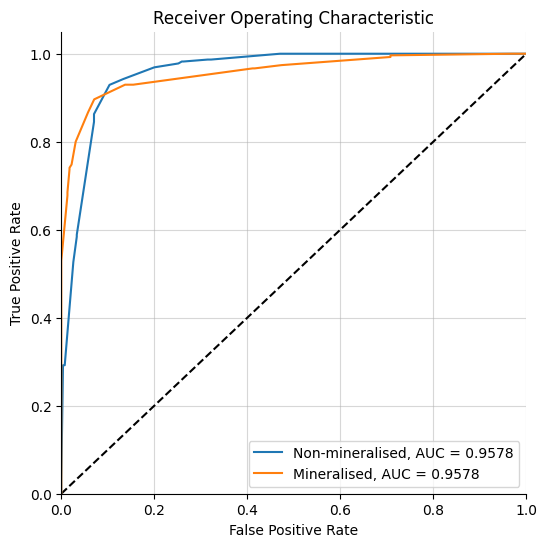

ROC AUC score: 0.9577597509013438


In [6]:
# Generate probability predictions for ROC analysis
labels_prob = model_rf_calibrated.predict_proba(features_rf_test)
labels_name = ["Non-mineralised", "Mineralised"]
# Create ROC plot
roc_plot(labels_rf_test, labels_prob, 2, labels_name)

### Feature Importance (Gini Importance)

Feature importance is a metric used by tree-based models like Random Forest to estimate the relative contribution of each feature to the model's predictions. It is computed by averaging the total reduction in Gini impurity (a measure of node impurity) brought by each feature across all trees in the forest. Features that more frequently and more significantly reduce impurity are considered more important. This helps in understanding which variables have the most influence in the model's decision-making process. We split the samples into five groups and train ten models using the same hyperparameters obtained through Bayesian optimisation. For each model, four groups are used for training while the remaining group is reserved for testing. The Gini importance of each feature is then calculated across all models, resulting in fifty values per feature. These values are visualised in a box plot, and the features are ranked from top to bottom according to their median importance.

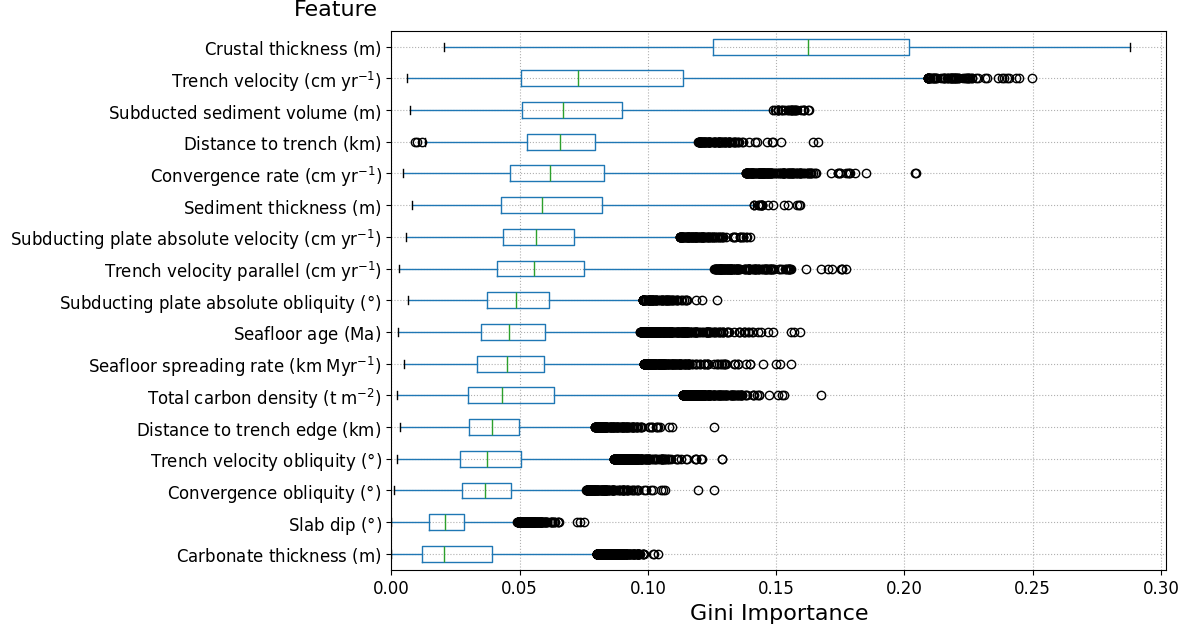

In [7]:
if os.path.isfile(gini_importances_filename):
    gini_importances = pd.read_csv(gini_importances_filename)
else:    
    # Setup
    n_splits = 5
    n_repeats = 10
    cv = RepeatedStratifiedKFold(
        n_splits=n_splits,
        n_repeats=n_repeats,
        random_state=42,
    )
    feature_names = features_rf_test.columns
    gini_importances_all = []

    # Cross-validate with the best estimator
    for idx, _ in cv.split(features_rf, labels_rf):
        features_fold = features_rf.iloc[idx]
        weights_fold = features_fold["weight"]
        features_fold = features_fold.drop("weight", axis=1)
        labels_fold = labels_rf.iloc[idx]

        # Clone and fit
        clf = clone(model_rf_calibrated.estimator)
        clf.fit(features_fold, labels_fold, sample_weight=weights_fold)

        # Extract per-tree importances
        tree_importances = pd.DataFrame(
            [tree.feature_importances_ for tree in clf.estimators_],
            columns=feature_names
        )
        gini_importances_all.append(tree_importances)

    # Combine all results into one DataFrame
    gini_importances = pd.concat(gini_importances_all, ignore_index=True)

    # Sort columns by median importance
    gini_importances = gini_importances[gini_importances.median().sort_values(ascending=False).index]

    # Save to CSV
    gini_importances.to_csv(gini_importances_filename, index=False)

# Plot
fig, ax = plt.subplots(figsize=(10, 7))

# Reverse column order so the most important is on top
gini_importances.iloc[:, ::-1].boxplot(vert=False, ax=ax)

# Customise plot
ax.grid(linestyle="dotted")
ax.set_xlim(0)
ax.set_xlabel("Gini Importance", fontsize=16)
ax.set_ylabel("Feature", rotation=0, ha="right", fontsize=16)
ax.yaxis.set_label_coords(-0.017, 1.02)

# Format y-tick labels
ax.set_yticks(
    ax.get_yticks(),
    [format_feature_name(label.get_text()) for label in ax.get_yticklabels()]
)

# Style tick labels
ax.tick_params(labelsize=12)

plt.show()

### Permutation Importance

Permutation importance is a model-agnostic technique used to evaluate the impact of each feature on a model's predictive performance. It works by randomly shuffling the values of a single feature in the test data and measuring how much the model's performance decreases. If permuting a feature's values significantly degrades the model's score (e.g., F1 score), it indicates that the feature is important. This method provides a more direct assessment of feature relevance than internal metrics like Gini importance, especially in the presence of feature interactions or correlations. Similar to the previous step, we split the samples into five groups and train ten models using the hyperparameters obtained through Bayesian optimisation. In each model, four groups are used for training and the remaining group is held out for testing. The permutation importance of each feature is then computed across all models, yielding fifty values per feature. These values are displayed in a box plot, and the features are ranked from top to bottom based on their median importance.

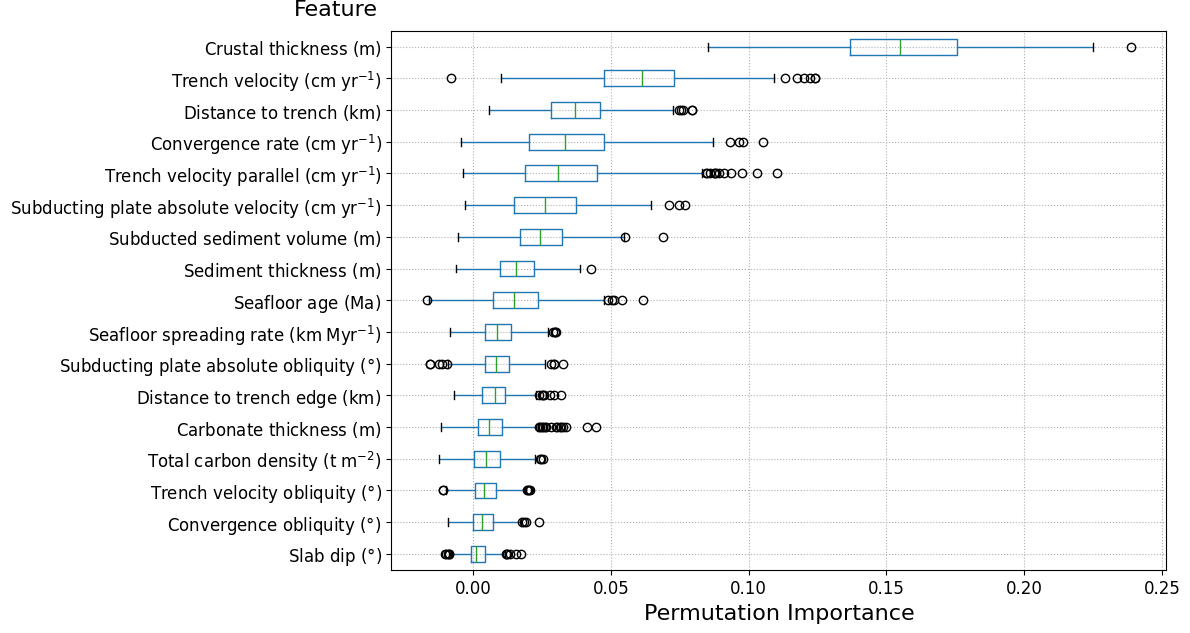

In [8]:
if os.path.isfile(permutation_importances_filename):
    permutation_importances = pd.read_csv(permutation_importances_filename)
else:
    # Setup
    n_splits = 5
    n_repeats = 10
    cv = RepeatedStratifiedKFold(
        n_splits=n_splits,
        n_repeats=n_repeats,
        random_state=42,
    )
    feature_names = features_rf_test.columns
    permutation_importances_all = []

    # Cross-validate with the best estimator
    for train_idx, test_idx in cv.split(features_rf, labels_rf):
        features_train = features_rf.iloc[train_idx]
        weights_train = features_train["weight"]
        features_train = features_train.drop("weight", axis=1)
        labels_train = labels_rf.iloc[train_idx]
        features_test = features_rf.iloc[test_idx]
        weights_test = features_test["weight"]
        features_test = features_test.drop("weight", axis=1)
        labels_test = labels_rf.iloc[test_idx]

        # Clone and fit
        clf = clone(model_rf_calibrated.estimator)
        clf.fit(features_train, labels_train, sample_weight=weights_train)

        result = permutation_importance(clf, features_test, labels_test, sample_weight=weights_test, scoring="f1", n_repeats=10, random_state=42, n_jobs=n_jobs)
        result_df = pd.DataFrame(result.importances.T, columns=feature_names)
        permutation_importances_all.append(result_df)

    # Combine all results into one DataFrame
    permutation_importances = pd.concat(permutation_importances_all, ignore_index=True)

    # Sort columns by median importance
    permutation_importances = permutation_importances[permutation_importances.median().sort_values(ascending=False).index]

    # Save to CSV
    permutation_importances.to_csv(permutation_importances_filename, index=False)

# Plot
fig, ax = plt.subplots(figsize=(10, 7))

# Reverse column order so the most important is on top
permutation_importances.iloc[:, ::-1].boxplot(vert=False, ax=ax)

# Customise plot
ax.grid(linestyle="dotted")
ax.set_xlabel("Permutation Importance", fontsize=16)
ax.set_ylabel("Feature", rotation=0, ha="right", fontsize=16)
ax.yaxis.set_label_coords(-0.017, 1.02)

# Format y-tick labels
ax.set_yticks(
    ax.get_yticks(),
    [format_feature_name(label.get_text()) for label in ax.get_yticklabels()]
)

# Style tick labels
ax.tick_params(labelsize=12)

plt.show()

### Partial Dependence and Individual Conditional Expectation

Partial Dependence Plots (PDPs) illustrate how individual features influence the model's predictions while averaging over all other features, making them useful for identifying general trends related to mineralisation. In contrast, Individual Conditional Expectation (ICE) curves show how predictions vary for individual samples, helping to detect unusual behaviour in specific zones. Both plots demonstrate how changes in a single feature affect the predicted probability of mineralisation while keeping other features constant. This cell is interactive, allowing you to select any input feature and explore its impact on model predictions—both on average and at the level of individual data points.

In [9]:
# Prepare data for PDP/ICE analysis
features_rf_train = Xy_rf_train.copy()
labels_rf_train = features_rf_train["label"]
weights_rf_train = features_rf_train["weight"]
features_rf_train = features_rf_train.drop(["weight", "label"], axis=1)
feature_names = features_rf_train.columns

# Load scaler to convert back to original units
robust_scaler = joblib.load(robust_scaler_filename)
features_rf_train_original_values = features_rf_train * robust_scaler.scale_ + robust_scaler.center_

@interact
def show_pdp_ice(feature=feature_names):
    plt.figure(figsize=(8, 6))

    # Compute partial dependence and ICE
    pd_result = partial_dependence(
        estimator=model_rf_calibrated.estimator,
        X=features_rf_train,
        features=[feature],
        sample_weight=weights_rf_train,
        kind="both", # 'both' shows PDP and ICE
        method="brute",
        grid_resolution=100,
        percentiles=(0.05, 0.95),
    )

    averaged = pd_result.average[0]
    individual = pd_result.individual[0]
    grid_values = pd_result.grid_values[0]

    # Plot ICE with label-based coloring
    for i, ice_line in enumerate(individual):
        label = labels_rf_train.iloc[i]
        color = "LightSalmon" if label == 1 else "DarkSeaGreen"
        plt.plot(grid_values, ice_line, color=color, alpha=0.3, linewidth=0.7)

    # Plot PDP
    plt.plot(grid_values, averaged, color="black", linewidth=2, linestyle="--")

    # Main x-axis ticks (outward, labeled, default spacing)
    plt.tick_params(axis="x", direction="out", length=6)

    # Add secondary inward ticks for percentiles (unlabelled)
    percentiles = np.linspace(5, 95, 11)
    percentile_values = np.percentile(features_rf_train_original_values[feature], percentiles)
    feature_min = features_rf_train_original_values[feature].quantile(0.05)
    feature_max = features_rf_train_original_values[feature].quantile(0.95)
    x_min = grid_values.min()
    x_max = grid_values.max()
    ax = plt.gca()
    plt.xlim(x_min, x_max)
    inward_tick_positions = (percentile_values - feature_min) / (feature_max - feature_min) * (x_max - x_min) + x_min

    for tick in inward_tick_positions:
        plt.axvline(x=tick, ymin=0, ymax=0.03, color="black", linewidth=1)

    x_ticks = ax.get_xticks()
    mask = (x_ticks >= x_min) & (x_ticks <= x_max)
    x_ticks = x_ticks[mask]
    ax.set_xticks(x_ticks)
    
    original_tick_values = feature_min + (x_ticks - x_min) * (feature_max - feature_min) / (x_max - x_min)
    original_tick_labels = [f"{val:.4f}" for val in original_tick_values]
    ax.set_xticklabels(original_tick_labels)
        
    # Axis labelling and title
    plt.xlabel(format_feature_name(feature))
    plt.ylabel("Partial dependence")
    plt.title(f"Partial Dependence and ICE for '{format_feature_name(feature)}'")    
    # Add legend
    pos_line = Line2D([], [], color="LightSalmon", alpha=0.6, label="Positive")
    neg_line = Line2D([], [], color="DarkSeaGreen", alpha=0.6, label="Negative")
    avg_line = Line2D([], [], color="black", linestyle="--", linewidth=2, label="Average")
    plt.legend(handles=[pos_line, neg_line, avg_line], loc="upper left")
    
    plt.show()

interactive(children=(Dropdown(description='feature', options=('carbonate_thickness (m)', 'convergence_obliqui…

### SHAP Values

SHAP (SHapley Additive exPlanations) values provide a unified measure of feature importance by quantifying how much each feature contributes to a specific prediction. Based on cooperative game theory, SHAP values fairly distribute the difference between a model's prediction and the average prediction among all input features. Unlike methods that only give global importance, SHAP values offer both global and local interpretability, showing not just which features are important, but also how they influence individual predictions—positively or negatively. We split the samples into five groups and train two models using the hyperparameters obtained through Bayesian optimisation. In each model, four groups are used for training and the remaining group is held out for testing. SHAP values for each feature is then computed across all models and the features are ranked from top to bottom based on their importance.

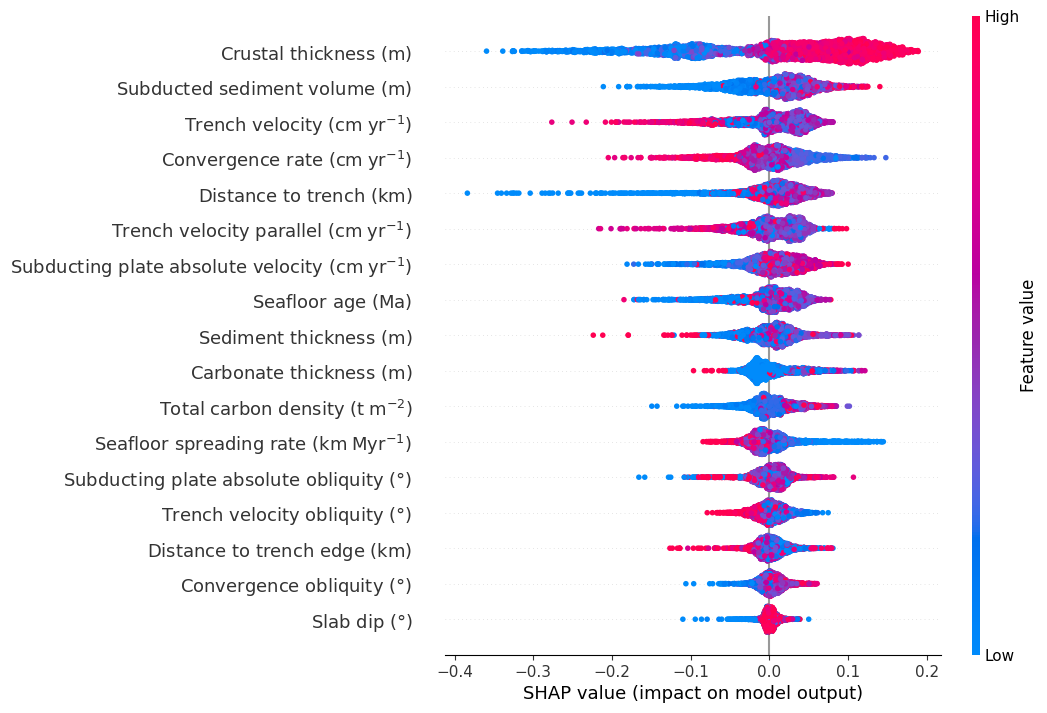

In [10]:
if os.path.isfile(shap_values_filename):
    # Load existing SHAP values and features if available
    shap_values = pd.read_csv(shap_values_filename)
    shap_values_array = shap_values.values
    features_shap_test = pd.read_csv(features_shap_test_filename)
    feature_names = features_rf_test.columns
else:
    # Setup
    n_splits = 5
    n_repeats = 2
    total_folds = n_splits * n_repeats
    
    cv = RepeatedStratifiedKFold(
        n_splits=n_splits,
        n_repeats=n_repeats,
        random_state=42,
    )
    
    test_idx_all = []
    shap_values_all = []

    # Cross-validate with the best estimator
    for train_idx, test_idx in tqdm(cv.split(features_rf, labels_rf), total=total_folds, desc="Computing SHAP"):
        features_train = features_rf.iloc[train_idx]
        weights_train = features_train["weight"]
        features_train = features_train.drop("weight", axis=1)
        labels_train = labels_rf.iloc[train_idx]
        
        features_test = features_rf.iloc[test_idx]
        weights_test = features_test["weight"]
        features_test = features_test.drop("weight", axis=1)
        labels_test = labels_rf.iloc[test_idx]
        test_idx_all.extend(test_idx)

        # Clone and fit
        clf = clone(model_rf)
        clf.fit(features_train, labels_train, sample_weight=weights_train)

        # Compute SHAP values on the test set
        explainer = shap.TreeExplainer(clf, features_train)  # Use training data as background
        result = explainer(features_test, check_additivity=False)
        shap_values_all.append(result)
    
    # Combine all SHAP values from all folds
    shap_values_array = np.vstack([sv.values[:, :, 1] for sv in shap_values_all])
    feature_names = features_rf_test.columns
    shap_values = pd.DataFrame(shap_values_array, columns=feature_names)
    
    # Save SHAP values and features for future use
    shap_values.to_csv(shap_values_filename, index=False)
    features_shap_test = features_rf.iloc[test_idx_all].drop("weight", axis=1)
    features_shap_test.to_csv(features_shap_test_filename, index=False)

feature_names = [format_feature_name(name) for name in feature_names]

# Create a SHAP explanation object for visualisation
explanation = shap.Explanation(
    values=shap_values_array,
    data=features_shap_test.values,
    feature_names=feature_names
)

# Plot SHAP values using a beeswarm plot
shap.plots.beeswarm(explanation, max_display=20)

### Calculate Probability, Entropy, and Vote Variance

We apply the trained model to the previously generated points within buffer zones that encompass arc–back arc environments to estimate:

- **Mineralisation Probability**: The model's confidence that geological conditions are favourable for deposit formation.  
- **Entropy**: A measure of prediction uncertainty (high entropy indicates greater model uncertainty).  
- **Vote Variance**: The variability among decision trees (high variance suggests conflicting results between trees).  

The resulting predictions are saved as global grids, highlighting where mineralisation is most likely and where the model is more or less confident. These grids make it possible to visualise variations in mineralisation probability, helping to identify both potential exploration targets and areas of uncertainty in the predictions.

In [11]:
if os.path.isfile(backarc_prob_filename):
    print(f"Probabilities have already been calculated and saved in {backarc_prob_filename}")
else:
    columns = [
        "lon",
        "lat",
        "present_lon",
        "present_lat",
        "age (Ma)",
    ]

    # Load points within arc–back arc environments along with their associated
    # feature values for prediction
    backarc_data = pd.read_csv(backarc_data_filename)
    backarc_data_out = backarc_data[columns]
    
    # Get the same feature names used in model training
    selected_features = model_rf_calibrated.feature_names_in_
    
    # Scale feature values using the same scaler as training
    backarc_data_scaled = backarc_data[selected_features]
    backarc_data_scaled = robust_scaler.transform(backarc_data_scaled)
    backarc_data_scaled = pd.DataFrame(backarc_data_scaled, columns=selected_features)
    backarc_data_scaled[columns_to_drop_backarc] = backarc_data[columns_to_drop_backarc]

    # Calculate probability and entropy values for all points
    # Entropy quantifies uncertainty in model predictions
    backarc_features = backarc_data_scaled[selected_features]
    probs = model_rf_calibrated.predict_proba(backarc_features)[:, 1].ravel()
    backarc_prob = backarc_data_out.copy()
    backarc_prob["probability"] = probs
    entropies = calculate_entropy(probs)
    backarc_prob["entropy"] = entropies
    
    # Calculate vote variance
    # Vote variance shows disagreement among decision trees
    chunk_size = 100000  # Adjust based on available memory
    n_samples = backarc_features.shape[0]
    n_chunks = (n_samples // chunk_size) + (1 if n_samples % chunk_size != 0 else 0)  # Ensure last chunk is included
    
    for i in tqdm(range(n_chunks)):
        start_idx = i * chunk_size
        end_idx = min((i + 1) * chunk_size, n_samples)
    
        X_chunk = backarc_features.iloc[start_idx:end_idx]
        
        # Calculate vote variance for the chunk
        vote_variances_chunk = calculate_tree_vote_variance(model_rf_calibrated.estimator, X_chunk.values)
        
        # Ensure that the chunk size matches the number of rows being processed
        if len(vote_variances_chunk) != (end_idx - start_idx):
            raise ValueError(f"Mismatch in size: {len(vote_variances_chunk)} vs. {end_idx - start_idx}")
        
        # Assign the result to the appropriate slice of the dataframe
        backarc_prob.loc[start_idx:end_idx-1, "vote_variance"] = vote_variances_chunk
    
    del probs
    backarc_prob.to_csv(backarc_prob_filename, index=False)
    del backarc_prob

# Create probability grids
if os.path.exists(backarc_prob_grids_dir):
    print(f"Probability grids are located in {backarc_prob_grids_dir}")
else:
    os.makedirs(backarc_prob_grids_dir, exist_ok=True)
    
    create_grids(
        data=backarc_prob_filename,
        output_dir=backarc_prob_grids_dir,
        times=time_steps,
        extent=(-180, 180, -90, 90),
        threads=n_jobs,
        verbose=True,
        column="probability",
        filename_format="backarc_probability_grid_{}Ma.nc",        
    )
    
# Create entropy grids
if os.path.exists(backarc_entropy_grids_dir):
    print(f"Entropy grids are located in {backarc_entropy_grids_dir}")
else:    
    os.makedirs(backarc_entropy_grids_dir, exist_ok=True)
    
    create_grids(
        data=backarc_prob_filename,
        output_dir=backarc_entropy_grids_dir,
        times=time_steps,
        extent=(-180, 180, -90, 90),
        threads=n_jobs,
        verbose=True,
        column="entropy",
        filename_format="backarc_entropy_grid_{}Ma.nc",        
    )
    
# Create vote variance grids
if os.path.exists(backarc_vote_variance_grids_dir):
    print(f"Vote variance grids are located in {backarc_vote_variance_grids_dir}")
else:    
    os.makedirs(backarc_vote_variance_grids_dir, exist_ok=True)
    
    create_grids(
        data=backarc_prob_filename,
        output_dir=backarc_vote_variance_grids_dir,
        times=time_steps,
        extent=(-180, 180, -90, 90),
        threads=n_jobs,
        verbose=True,
        column="vote_variance",
        filename_format="backarc_vote_variance_grid_{}Ma.nc",        
    )

Probabilities have already been calculated and saved in outputs\ml\backarc_prob.csv
Probability grids are located in outputs\ml\backarc_prob_grids
Entropy grids are located in outputs\ml\backarc_entropy_grids
Vote variance grids are located in outputs\ml\backarc_vote_variance_grids


### Probability Maps

The cell below loads the required files to create the `PlateReconstruction` and `PlateTopologies` objects, which will later be used to map mineralisation probability, entropy, and vote variance through geological time at a global scale.

In [12]:
# STELLAR4A plate motion model
rotation_model = plate_model_dir+"/CombinedRotations.rot"

topology_features = [
    plate_model_dir+"/Deforming_Networks_Active.gpml",
    plate_model_dir+"/Deforming_Networks_Inactive.gpml",
    plate_model_dir+"/Feature_Geometries.gpml",
    # plate_model_dir+"/Flat_Slabs.gpml", # Including this file may introduce artifacts, so it is recommended to exclude it when creating the PlateReconstruction object.
    plate_model_dir+"/Plate_Boundaries.gpml",
]

static_polygons = plate_model_dir+"/Global_EarthByte_GPlates_PresentDay_StaticPlatePolygons.gpml"
coastlines = plate_model_dir+"/Global_coastlines_low_res.gpml"
continents = plate_model_dir+"/Global_EarthByte_GPlates_PresentDay_ContinentsAndArcs.gpml"
COBs = plate_model_dir+"/Global_EarthByte_GeeK07_COBLineSegments_2019_v1.gpml"

plate_reconstruction = PlateReconstruction(
    rotation_model=rotation_model,
    topology_features=topology_features,
    static_polygons=static_polygons,
)

gplot = PlotTopologies(
    plate_reconstruction=plate_reconstruction,
    coastlines=coastlines,
    continents=continents,
    COBs=COBs,
)

# Define map projection (Mollweide provides a good global view) and central meridian
projection = ccrs.Mollweide(central_longitude=60)
central_meridian = 0

This section creates an interactive probability map showing mineralisation probability along trench lines, together with known mineral occurrences. It also plots seafloor age and plate boundaries, including mid-ocean ridges and transform faults, at a selected time. The visualisation highlights spatial patterns, showing how mineralisation probability relates to tectonic features, and temporal evolution, showing how favourable conditions migrate through time.

In [13]:
@interact
def show_map(time=time_steps):
    gplot.time = time # Set reconstruction time
    fig = plot(
        gplot=gplot,
        grid=os.path.join(
            backarc_prob_grids_dir,
            f"backarc_probability_grid_{time:0.0f}Ma.nc", # Mineralisation probability grid
        ),
        grid_type="probability",
        background_grid=os.path.join(
            agegrid_dir,
            f"seafloor_age_{time:0.0f}Ma.nc", # Seafloor age grid
        ),
        positives=deposit_coords_recon_all_filename, # Reconstructed location of known mineral occurrences
        projection=projection,
        time=time,
        central_meridian=central_meridian,
    )

interactive(children=(Dropdown(description='time', options=(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, …

The cell below generates a full sequence of mineralisation probability maps through geological time and compiles them into a time-lapse animation, illustrating how the modelled probability of mineralisation changes over time.

In [14]:
# Generate all probability maps and create animation
if os.path.exists(backarc_prob_maps_dir):
    print(f"Probability maps are located in {backarc_prob_maps_dir}")
else:
    os.makedirs(backarc_prob_maps_dir, exist_ok=True)

    # Create maps in parallel for efficiency
    with Parallel(
        n_jobs=n_jobs,
        verbose=True,
        pre_dispatch="all",
        batch_size=int(len(time_steps) // n_jobs) + 1,
    ) as parallel:

        # Define output filename for each time step
        output_filenames = [
            os.path.join(backarc_prob_maps_dir, f"backarc_probability_map_{t:0.0f}Ma.png")
            for t in time_steps
        ]

        parallel(
            delayed(plot_parallel)(
                rotation_model,
                topology_features,
                static_polygons,
                coastlines,
                continents,
                COBs,
                grid=os.path.join(
                    backarc_prob_grids_dir,
                    f"backarc_probability_grid_{t:0.0f}Ma.nc",
                ),
                grid_type="probability",
                background_grid=os.path.join(
                    agegrid_dir,
                    f"seafloor_age_{t:0.0f}Ma.nc",
                ),
                positives=deposit_coords_recon_all_filename,
                projection=projection,
                time=t,
                output_filename=o,
                central_meridian=central_meridian,
            )
            for t, o in zip(time_steps, output_filenames)
        )

    # Create an animation showing the evolution of mineralisation probability
    # Animation reveals temporal patterns in geological processes
    output_filename = os.path.join(ml_dir, "backarc_probability_animation.mp4")
    create_animation(
        image_filenames=output_filenames[::-1],
        output_filename=output_filename,
        fps=10,
        bitrate="5000k",
    )

Probability maps are located in outputs\ml\backarc_prob_maps


### Entropy Maps

This section generates an interactive entropy map along trench lines, combined with known mineral occurrences. It also displays seafloor age and plate boundaries—including mid-ocean ridges and transform faults—at a chosen time step.

Entropy is a statistical measure of uncertainty in the model's probability predictions:

- **Low entropy (≈ 0):** The model is confident. Predictions lean strongly toward either a high or low probability of mineralisation.
- **High entropy (≈ 1):** The model is uncertain. Probabilities cluster near 50%, indicating ambiguity about whether conditions favour or hinder deposit formation.

Entropy maps allow you to explore how spatial uncertainty in mineralisation changes through geological time. By sliding across different time steps, you can visualise regions where the model's predictions are most confident versus where they remain uncertain.

In [15]:
@interact
def show_map(time=time_steps):
    gplot.time = time # Set reconstruction time
    fig = plot(
        gplot=gplot,
        grid=os.path.join(
            backarc_entropy_grids_dir,
            f"backarc_entropy_grid_{time:0.0f}Ma.nc", # Entropy grid
        ),
        grid_type="entropy",
        background_grid=os.path.join(
            agegrid_dir,
            f"seafloor_age_{time:0.0f}Ma.nc", # Seafloor age grid
        ),
        positives=deposit_coords_recon_all_filename, # Reconstructed location of known mineral occurrences
        projection=projection,
        time=time,
        central_meridian=central_meridian,
    )

interactive(children=(Dropdown(description='time', options=(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, …

The cell below generates a complete sequence of entropy maps through geological time and compiles them into a time-lapse animation. This visualisation shows how entropy evolves over time, providing an intuitive way to communicate model uncertainty across Earth's history. Such animations are especially useful for identifying when and where the predictive model is most stable or most variable.

In [16]:
# Generate all entropy maps and create animation
if os.path.exists(backarc_entropy_maps_dir):
    print(f"Entropy maps are located in {backarc_entropy_maps_dir}")
else:
    os.makedirs(backarc_entropy_maps_dir, exist_ok=True)

    # Create maps in parallel for efficiency
    with Parallel(
        n_jobs=n_jobs,
        verbose=True,
        pre_dispatch="all",
        batch_size=int(len(time_steps) // n_jobs) + 1,
    ) as parallel:

        # Define output filename for each time step
        output_filenames = [
            os.path.join(backarc_entropy_maps_dir, f"backarc_entropy_map_{t:0.0f}Ma.png")
            for t in time_steps
        ]

        parallel(
            delayed(plot_parallel)(
                rotation_model,
                topology_features,
                static_polygons,
                coastlines,
                continents,
                COBs,
                grid=os.path.join(
                    backarc_entropy_grids_dir,
                    f"backarc_entropy_grid_{t:0.0f}Ma.nc",
                ),
                grid_type="entropy",
                background_grid=os.path.join(
                    agegrid_dir,
                    f"seafloor_age_{t:0.0f}Ma.nc",
                ),
                positives=deposit_coords_recon_all_filename,
                projection=projection,
                time=t,
                output_filename=o,
                central_meridian=central_meridian,
            )
            for t, o in zip(time_steps, output_filenames)
        )

    # Create an animation showing the changes in entropy through geological time
    output_filename = os.path.join(ml_dir, "backarc_entropy_animation.mp4")
    create_animation(
        image_filenames=output_filenames[::-1],
        output_filename=output_filename,
        fps=10,
        bitrate="5000k",
    )

Entropy maps are located in outputs\ml\backarc_entropy_maps


### Vote Variance Maps

Vote variance maps illustrate model disagreement—showing where different iterations of a predictive model produce varying estimates of mineralisation likelihood. Each tree in the Random Forest casts a vote for a given location, predicting either the presence, absence, or probability of mineralisation. The vote variance is then calculated as the statistical variance of these votes across all trees.

High vote variance indicates less agreement between models, highlighting uncertainty in the geological features driving mineralisation. Conversely, low variance reflects model consensus and suggests more stable predictive signals.

The following code segment generates an interactive plot of a vote variance map for a selected geological time, enabling users to explore model agreement and disagreement in predicted mineral prospectivity through time.

In [17]:
@interact
def show_map(time=time_steps):
    gplot.time = time # Set reconstruction time
    fig = plot(
        gplot=gplot,
        grid=os.path.join(
            backarc_vote_variance_grids_dir,
            f"backarc_vote_variance_grid_{time:0.0f}Ma.nc", # Vote variance grid
        ),
        grid_type="vote variance",
        background_grid=os.path.join(
            agegrid_dir,
            f"seafloor_age_{time:0.0f}Ma.nc", # Seafloor age grid
        ),
        positives=deposit_coords_recon_all_filename, # Reconstructed location of known mineral occurrences
        projection=projection,
        time=time,
        central_meridian=central_meridian,
    )

interactive(children=(Dropdown(description='time', options=(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, …

The cell below generates a full sequence of vote variance maps across geological time and compiles them into a time-lapse animation. This visualisation highlights where model consensus on mineralisation is strong or weak at each time step.

In [18]:
# Generate all vote variance maps and create animation
if os.path.exists(backarc_vote_variance_maps_dir):
    print(f"Vote variance maps are located in {backarc_vote_variance_maps_dir}")
else:
    os.makedirs(backarc_vote_variance_maps_dir, exist_ok=True)

    # Create maps in parallel for efficiency
    with Parallel(
        n_jobs=n_jobs,
        verbose=True,
        pre_dispatch="all",
        batch_size=int(len(time_steps) // n_jobs) + 1,
    ) as parallel:

        # Define output filename for each time step
        output_filenames = [
            os.path.join(backarc_vote_variance_maps_dir, f"backarc_vote_variance_map_{t:0.0f}Ma.png")
            for t in time_steps
        ]

        parallel(
            delayed(plot_parallel)(
                rotation_model,
                topology_features,
                static_polygons,
                coastlines,
                continents,
                COBs,
                grid=os.path.join(
                    backarc_vote_variance_grids_dir,
                    f"backarc_vote_variance_grid_{t:0.0f}Ma.nc",
                ),
                grid_type="vote variance",
                background_grid=os.path.join(
                    agegrid_dir,
                    f"seafloor_age_{t:0.0f}Ma.nc",
                ),
                positives=deposit_coords_recon_all_filename,
                projection=projection,
                time=t,
                output_filename=o,
                central_meridian=central_meridian,
            )
            for t, o in zip(time_steps, output_filenames)
        )

    # Create an animation showing the changes in vote variance through geological time
    output_filename = os.path.join(ml_dir, "backarc_vote_variance_animation.mp4")
    create_animation(
        image_filenames=output_filenames[::-1],
        output_filename=output_filename,
        fps=10,
        bitrate="5000k",
    )

Vote variance maps are located in outputs\ml\backarc_vote_variance_maps
